# 中文文本层次聚类（教学版·独立运行）

本Notebook不调用外部Python程序。处理流程为：参数设置 → 文件读取 → Jieba分词与词性筛选 → 停用词和同义词处理 → 数据矩阵 → 距离与层次聚类 → 树状图 → 双向聚类热图。

请从上到下依次运行各单元格。各通用步骤均放在独立单元格中，便于在其他文本分析方法中复用。


## 0. 安装所需软件包

第一次运行时，请删除下一行开头的 # 后执行。安装完成后如有必要，请重新启动内核。


In [41]:
# %pip install numpy scipy matplotlib pandas jieba seaborn


## 1. 全部参数设置

所有可选参数集中在这里。

特别注意：

- **CLUSTER_MATRIX_TYPE** 明确指定层次聚类使用的数据矩阵，可选 relative（相对频率）或 tfidf。
- **TOP_N_FEATURES** 指定按全体语料总出现频数排序后保留的前N个变量。设为0时使用全部变量。
- **HEATMAP_TOP_VARIABLES** 指定双向聚类热图使用的前N个变量。


In [42]:
from pathlib import Path

# ==================== 输入与输出 ====================
INPUT_DIR = Path(r"C:\Desktop\讲座课件\zhuowen\c_text")
OUTPUT_DIR = Path(r"C:\temp\hierarchical_clustering_results")
ENCODING = "utf-8-sig"
READ_RECURSIVELY = True

# ==================== 分词与词语处理 ====================
# Jieba词性前缀：n=名词，v=动词，a=形容词；空列表 [] 表示保留全部词性。
POS_PREFIXES = ["n"] #, "v", "a"]
STOPWORDS = {"的", "了", "和", "是", "在", "也", "有", "与", "及", "等", "一个",
            "真纪","人","时","地方"}
# 可另外指定UTF-8停用词文件，每行一个词；不使用时设为None。
STOPWORD_FILE = None
REMOVE_DIGITS = True
REMOVE_LATIN = True
MIN_TOKEN_LENGTH = 1
CUSTOM_WORDS = []
# 将右侧同义词统一替换为左侧代表词。
SYNONYM_GROUPS = {
    "计算机": ["电脑", "微机"],
    "互联网": ["网络", "因特网"],
}

# ==================== 变量筛选与数据矩阵 ====================
MIN_DOCUMENT_FREQUENCY = 1
# 按全体语料总出现频数从高到低保留前N个变量；0表示全部保留。
TOP_N_FEATURES = 300

# 【层次聚类使用的数据在此指定】
# relative = 相对频率；tfidf = TF-IDF（其中TF采用相对频率）。
CLUSTER_MATRIX_TYPE = "tfidf"  # relative / tfidf

# ==================== 层次聚类 ====================
LINKAGE_METHOD = "ward"
# single / complete / average / mcquitty / centroid / median / ward
DISTANCE = "hellinger"
# euclidean / manhattan / cosine / hellinger / jsd
N_CLUSTERS = 2

# ==================== 树状图 ====================
LABEL_LENGTH = 8
DENDROGRAM_ORIENTATION = "top"  # top / right / bottom / left
FIGURE_DPI = 300

# ==================== 双向聚类热图 ====================
# 热图使用的数据矩阵；可与层次聚类使用的矩阵不同。
HEATMAP_MATRIX_TYPE = "relative"  # relative / tfidf
# 按总出现频数从高到低选择前N个变量绘图。
HEATMAP_TOP_VARIABLES = 50
HEATMAP_COLUMN_LINKAGE = "ward"
HEATMAP_COLUMN_METRIC = "euclidean"
HEATMAP_STANDARD_SCALE = None  # None / 0（按变量）/ 1（按文档）

# ==================== Notebook显示 ====================
TABLE_PREVIEW_ROWS = 6
MATRIX_PREVIEW_SIZE =6


## 2. 导入软件包


In [43]:
import json
import math
import re
import unicodedata
from collections import Counter

import jieba
import jieba.posseg as pseg
import matplotlib
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors
from matplotlib import font_manager
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
from scipy.cluster.hierarchy import cut_tree, dendrogram, linkage
from scipy.spatial.distance import jensenshannon, pdist, squareform

print("软件包导入完成。")


软件包导入完成。


## 3. 通用部分A：读取文件与生成标签

读取输入文件夹中的全部UTF-8文件。标签取不含扩展名的文件名前若干字符；相同标签会自动添加序号。


In [44]:
def collect_files(folder):
    pattern = "**/*" if READ_RECURSIVELY else "*"
    return sorted(
        [path for path in folder.glob(pattern) if path.is_file()],
        key=lambda path: str(path.relative_to(folder)).casefold()
    )


def read_documents(paths):
    valid_paths, texts = [], []
    for path in paths:
        text = unicodedata.normalize("NFC", path.read_text(encoding=ENCODING))
        if text.strip():
            valid_paths.append(path)
            texts.append(text)
        else:
            print("警告：已排除空文件：", path)
    return valid_paths, texts


def make_unique_labels(paths):
    labels, counts = [], Counter()
    for path in paths:
        base = unicodedata.normalize("NFC", path.stem)[:LABEL_LENGTH]
        counts[base] += 1
        suffix = "（{}）".format(counts[base]) if counts[base] > 1 else ""
        labels.append(base + suffix)
    return labels


## 4. 通用部分B：Jieba分词、词性、停用词与同义词

本单元格完成可复用于其他文本分析的预处理：

1. 使用Jieba进行分词和词性标注；
2. 只保留指定词性；
3. 删除停用词；
4. 按设置删除含数字或英文字母的词；
5. 将同义词合并为代表词。


In [45]:
DIGIT_PATTERN = re.compile(r"[0-9０-９]")
LATIN_PATTERN = re.compile(r"[A-Za-zＡ-Ｚａ-ｚ]")


def load_stopwords():
    words = {
        unicodedata.normalize("NFC", str(word).strip())
        for word in STOPWORDS if str(word).strip()
    }
    if STOPWORD_FILE:
        extra = Path(STOPWORD_FILE).read_text(encoding="utf-8-sig").splitlines()
        words.update(
            unicodedata.normalize("NFC", word.strip())
            for word in extra if word.strip()
        )
    return words


def build_synonym_map():
    mapping = {}
    for canonical, variants in SYNONYM_GROUPS.items():
        canonical = unicodedata.normalize("NFC", canonical.strip())
        mapping[canonical] = canonical
        for variant in variants:
            mapping[unicodedata.normalize("NFC", variant.strip())] = canonical
    return mapping


def tokenize_documents(texts):
    for word in CUSTOM_WORDS:
        jieba.add_word(word)

    stopwords = load_stopwords()
    synonyms = build_synonym_map()
    tokenized = []

    for text in texts:
        tokens = []
        for word, pos in pseg.cut(text):
            token = unicodedata.normalize("NFC", word.strip())
            if not token:
                continue
            if POS_PREFIXES and not any(pos.startswith(prefix) for prefix in POS_PREFIXES):
                continue
            if len(token) < MIN_TOKEN_LENGTH:
                continue
            if all(unicodedata.category(ch).startswith(("P", "S", "Z")) for ch in token):
                continue
            if REMOVE_DIGITS and DIGIT_PATTERN.search(token):
                continue
            if REMOVE_LATIN and LATIN_PATTERN.search(token):
                continue
            if token in stopwords:
                continue
            token = synonyms.get(token, token)
            if token not in stopwords:
                tokens.append(token)
        tokenized.append(tokens)

    empty_rows = [index for index, tokens in enumerate(tokenized) if not tokens]
    if empty_rows:
        raise ValueError(
            "部分文档预处理后没有可用词语。请检查词性、停用词及字符筛选设置。"
            "文档位置：{}".format(empty_rows)
        )
    return tokenized, stopwords


## 5. 通用部分C：高频变量筛选与三种数据矩阵

先汇总全部文档的词语出现频数，再按总频数从高到低排序。TOP_N_FEATURES控制实际进入矩阵的变量数。

同时生成：

- 出现频数矩阵；
- 相对频率矩阵；
- TF-IDF矩阵。TF使用相对频率，IDF使用 log((N+1)/(df+1))+1。

词汇统计表也按总频数从高到低保存和显示。


In [46]:
def build_matrices(tokenized):
    counters = [Counter(tokens) for tokens in tokenized]
    total_frequency = Counter()
    document_frequency = Counter()

    for counter in counters:
        total_frequency.update(counter)
        document_frequency.update(counter.keys())

    ranked_words = [
        word for word, _ in total_frequency.most_common()
        if document_frequency[word] >= MIN_DOCUMENT_FREQUENCY
    ]
    if TOP_N_FEATURES > 0:
        ranked_words = ranked_words[:TOP_N_FEATURES]
    if not ranked_words:
        raise ValueError("没有满足筛选条件的变量，请修改变量筛选参数。")

    vocabulary = ranked_words
    word_to_column = {word: index for index, word in enumerate(vocabulary)}
    count_matrix = np.zeros((len(counters), len(vocabulary)), dtype=float)

    for row, counter in enumerate(counters):
        for word, count in counter.items():
            if word in word_to_column:
                count_matrix[row, word_to_column[word]] = count

    row_sums = count_matrix.sum(axis=1, keepdims=True)
    if np.any(row_sums == 0):
        raise ValueError("筛选高频变量后，部分文档没有可用词语。请增大TOP_N_FEATURES。")

    relative_matrix = count_matrix / row_sums
    df_values = np.count_nonzero(count_matrix > 0, axis=0)
    idf_values = np.log((len(counters) + 1) / (df_values + 1)) + 1
    tfidf_matrix = relative_matrix * idf_values

    vocabulary_statistics = pd.DataFrame({
        "排名": np.arange(1, len(vocabulary) + 1),
        "变量": vocabulary,
        "总出现频数": [total_frequency[word] for word in vocabulary],
        "出现文档数": [document_frequency[word] for word in vocabulary],
        "IDF": idf_values,
    })
    return (
        vocabulary, count_matrix, relative_matrix,
        tfidf_matrix, vocabulary_statistics
    )


## 6. 通用部分D：距离与层次聚类

CLUSTER_MATRIX_TYPE决定聚类使用相对频率还是TF-IDF。

Hellinger距离使用 sqrt(相对频率)/sqrt(2) 后的欧氏距离。因此，要求欧氏空间的centroid、median和ward方法也可以使用Hellinger距离。JSD同样基于相对频率计算。


In [47]:
LINKAGE_ALIASES = {
    "single": "single",
    "complete": "complete",
    "average": "average",
    "upgma": "average",
    "mcquitty": "weighted",
    "weighted": "weighted",
    "wpgma": "weighted",
    "centroid": "centroid",
    "median": "median",
    "ward": "ward",
}
EUCLIDEAN_SPACE_METHODS = {"centroid", "median", "ward"}


def select_analysis_matrix(matrix_type, relative_matrix, tfidf_matrix):
    matrices = {"relative": relative_matrix, "tfidf": tfidf_matrix}
    if matrix_type not in matrices:
        raise ValueError("数据矩阵只能选择relative或tfidf。")
    return matrices[matrix_type]


def hellinger_coordinates(relative_matrix):
    return np.sqrt(relative_matrix) / math.sqrt(2.0)


def perform_clustering(selected_matrix, relative_matrix):
    if LINKAGE_METHOD not in LINKAGE_ALIASES:
        raise ValueError("不支持的层次聚类方法：" + LINKAGE_METHOD)

    method = LINKAGE_ALIASES[LINKAGE_METHOD]
    if DISTANCE == "hellinger":
        coordinates = hellinger_coordinates(relative_matrix)
        condensed = pdist(coordinates, metric="euclidean")
    elif DISTANCE == "jsd":
        condensed = pdist(
            relative_matrix,
            metric=lambda left, right: float(
                jensenshannon(left, right, base=2.0)
            )
        )
    elif DISTANCE == "manhattan":
        condensed = pdist(selected_matrix, metric="cityblock")
    elif DISTANCE in {"euclidean", "cosine"}:
        condensed = pdist(selected_matrix, metric=DISTANCE)
    else:
        raise ValueError("不支持的距离：" + DISTANCE)

    if not np.all(np.isfinite(condensed)):
        raise ValueError("距离矩阵中存在NaN或无穷大。")

    if method in EUCLIDEAN_SPACE_METHODS:
        if DISTANCE == "euclidean":
            observations = selected_matrix
        elif DISTANCE == "hellinger":
            observations = hellinger_coordinates(relative_matrix)
        else:
            raise ValueError(
                "{}方法只能使用euclidean或hellinger距离。".format(
                    LINKAGE_METHOD
                )
            )
        tree = linkage(
            observations, method=method,
            metric="euclidean", optimal_ordering=True
        )
    else:
        tree = linkage(condensed, method=method, optimal_ordering=True)

    return condensed, tree, method


## 7. 通用部分E：树状图与配色

当分为两个聚类时，固定使用暖色橙红和冷色蓝。聚类数更多时，使用对比度较高的定性色板。


In [48]:
def choose_chinese_font():
    candidates = [
        "Microsoft YaHei", "Microsoft JhengHei", "SimHei", "SimSun",
        "Noto Sans CJK SC", "Source Han Sans SC", "Arial Unicode MS"
    ]
    available = {font.name for font in font_manager.fontManager.ttflist}
    for candidate in candidates:
        if candidate in available:
            matplotlib.rcParams["font.sans-serif"] = [candidate, "DejaVu Sans"]
            matplotlib.rcParams["axes.unicode_minus"] = False
            return candidate
    return None


def make_cluster_palette(cluster_ids):
    unique_ids = sorted(set(int(value) for value in cluster_ids))
    if len(unique_ids) == 2:
        return {
            unique_ids[0]: "#D55E00",
            unique_ids[1]: "#0072B2",
        }
    palette = sns.color_palette("Set1", n_colors=max(3, len(unique_ids)))
    return {
        cluster_id: mcolors.to_hex(palette[index])
        for index, cluster_id in enumerate(unique_ids)
    }


def calculate_node_memberships(tree, cluster_ids):
    sample_count = len(cluster_ids)
    memberships = {
        index: {int(cluster_ids[index])}
        for index in range(sample_count)
    }
    for row_index, row in enumerate(tree):
        left, right = int(row[0]), int(row[1])
        memberships[sample_count + row_index] = (
            memberships[left] | memberships[right]
        )
    return memberships


def draw_dendrogram(tree, labels, cluster_ids, output_path):
    colors = make_cluster_palette(cluster_ids)
    memberships = calculate_node_memberships(tree, cluster_ids)

    def branch_color(node_id):
        contained = memberships[int(node_id)]
        if len(contained) == 1:
            return colors[next(iter(contained))]
        return "#777777"

    sample_count = len(labels)
    if DENDROGRAM_ORIENTATION in {"top", "bottom"}:
        figure_size = (max(12.0, sample_count * 0.48), 8.5)
    else:
        figure_size = (14.0, max(9.0, sample_count * 0.32))

    fig, ax = plt.subplots(figsize=figure_size)
    dendrogram(
        tree, labels=labels, orientation=DENDROGRAM_ORIENTATION,
        leaf_rotation=90 if DENDROGRAM_ORIENTATION in {"top", "bottom"} else 0,
        leaf_font_size=9, link_color_func=branch_color,
        above_threshold_color="#777777", ax=ax
    )

    label_to_cluster = dict(zip(labels, cluster_ids))
    ticks = (
        ax.get_xticklabels()
        if DENDROGRAM_ORIENTATION in {"top", "bottom"}
        else ax.get_yticklabels()
    )
    for tick in ticks:
        cluster_id = label_to_cluster.get(tick.get_text())
        if cluster_id is not None:
            tick.set_color(colors[int(cluster_id)])
            tick.set_fontweight("bold")

    ax.set_title(
        "层次聚类树状图｜方法={}，距离={}，数据={}".format(
            LINKAGE_METHOD, DISTANCE, CLUSTER_MATRIX_TYPE
        )
    )
    ax.set_ylabel("距离")
    ax.grid(alpha=0.2)
    fig.tight_layout()
    fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    return colors


## 8. 通用部分F：双向聚类热图（Bi-cluster map）

按总出现频数选择前HEATMAP_TOP_VARIABLES个变量。文档方向沿用正文的层次聚类树，变量方向则根据变量在各文档中的分布再次进行层次聚类。

HEATMAP_MATRIX_TYPE可单独指定热图使用相对频率或TF-IDF。


In [49]:
def draw_bicluster_heatmap(
    relative_df, tfidf_df, vocabulary_statistics,
    row_tree, cluster_ids, cluster_colors, output_path
):
    matrix_options = {"relative": relative_df, "tfidf": tfidf_df}
    if HEATMAP_MATRIX_TYPE not in matrix_options:
        raise ValueError("热图数据只能选择relative或tfidf。")

    ranked_variables = vocabulary_statistics["变量"].tolist()
    if HEATMAP_TOP_VARIABLES > 0:
        ranked_variables = ranked_variables[:HEATMAP_TOP_VARIABLES]
    heatmap_data = matrix_options[HEATMAP_MATRIX_TYPE][ranked_variables]

    if heatmap_data.shape[1] >= 2:
        column_distances = pdist(
            heatmap_data.T.values, metric=HEATMAP_COLUMN_METRIC
        )
        column_tree = linkage(
            column_distances, method=HEATMAP_COLUMN_LINKAGE,
            optimal_ordering=True
        )
        use_column_clustering = True
    else:
        column_tree = None
        use_column_clustering = False

    row_colors = pd.Series(
        [cluster_colors[int(value)] for value in cluster_ids],
        index=heatmap_data.index,
        name="聚类"
    )

    grid = sns.clustermap(
        heatmap_data,
        row_linkage=row_tree,
        col_linkage=column_tree,
        row_cluster=True,
        col_cluster=use_column_clustering,
        row_colors=row_colors,
        cmap="YlOrRd",
        standard_scale=HEATMAP_STANDARD_SCALE,
        figsize=(max(12, heatmap_data.shape[1] * 0.42), 10),
        xticklabels=True,
        yticklabels=True,
    )
    grid.fig.suptitle(
        "双向聚类热图｜数据={}，高频变量数={}".format(
            HEATMAP_MATRIX_TYPE, len(ranked_variables)
        ),
        y=1.02
    )
    grid.ax_heatmap.set_xlabel("变量（按列聚类后显示）")
    grid.ax_heatmap.set_ylabel("文档（按行聚类后显示）")
    grid.fig.savefig(output_path, dpi=FIGURE_DPI, bbox_inches="tight")
    plt.show()
    plt.close(grid.fig)
    return heatmap_data


## 9. 运行、显示并保存结果

结果保存到 C:/temp/hierarchical_clustering_results。Notebook中同时显示高频变量、分析矩阵、聚类结果、树状图和双向聚类热图。


### 运行条件

,项目,设置值
0,文档数,22
1,实际变量数,300
2,聚类使用的数据矩阵,tfidf
3,层次聚类方法,ward
4,距离,hellinger
5,聚类数,2
6,热图使用的数据矩阵,relative
7,热图变量数,50
8,保存位置,C:\temp\hierarchical_clustering_results


### 高频变量统计

,排名,变量,总出现频数,出现文档数,IDF
0,1,电影院,129,11,1.650588
1,2,电影,94,11,1.650588
2,3,学校,72,10,1.737599
3,4,录像带,37,7,2.056053
4,5,大学,31,11,1.650588
5,6,事,24,10,1.737599


### 分词结果

...

### 文档聚类结果

,聚类,标签,文件名,相对路径,分词数
0,1,akke3,akke3.txt,akke3.txt,69
1,1,ataka3,ataka3.txt,ataka3.txt,89
2,1,kana3,kana3.txt,kana3.txt,71
3,1,kato3,kato3.txt,kato3.txt,87
4,1,kumi3,kumi3.txt,kumi3.txt,90
5,1,mari3,mari3.txt,mari3.txt,69
6,1,nogu3,nogu3.txt,nogu3.txt,87
7,1,oota3,oota3.txt,oota3.txt,81
8,1,ori3,ori3.txt,ori3.txt,96
9,1,taka3,taka3.txt,taka3.txt,93


### 距离矩阵

,akke3,akke8,ataka3,ataka8,kana3,kana8
akke3,0.00000,0.94435,0.82550,0.96880,0.81655,0.98260
akke8,0.94435,0.00000,0.90861,0.80229,0.90485,0.77688
ataka3,0.82550,0.90861,0.00000,0.94717,0.82292,0.98734
ataka8,0.96880,0.80229,0.94717,0.00000,0.94983,0.79070
kana3,0.81655,0.90485,0.82292,0.94983,0.00000,0.97093
kana8,0.98260,0.77688,0.98734,0.79070,0.97093,0.00000


### 层次聚类树状图

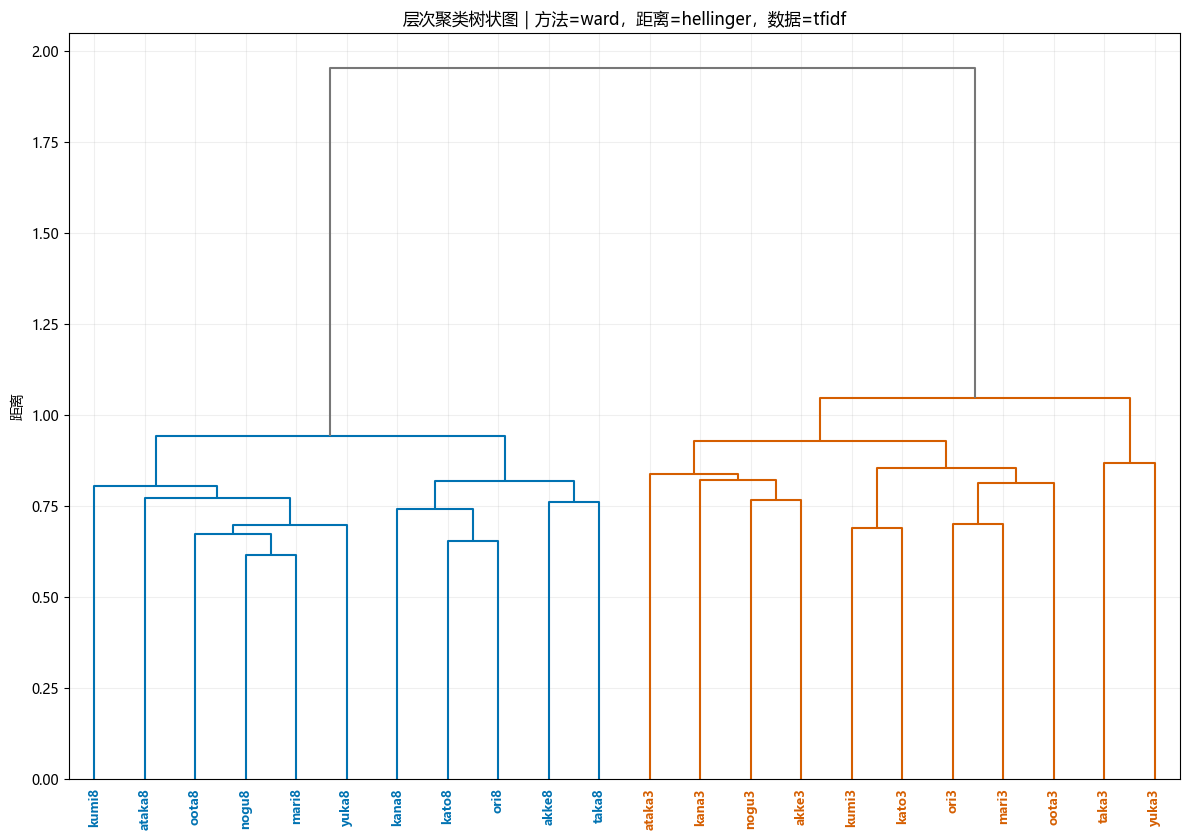

### 双向聚类热图

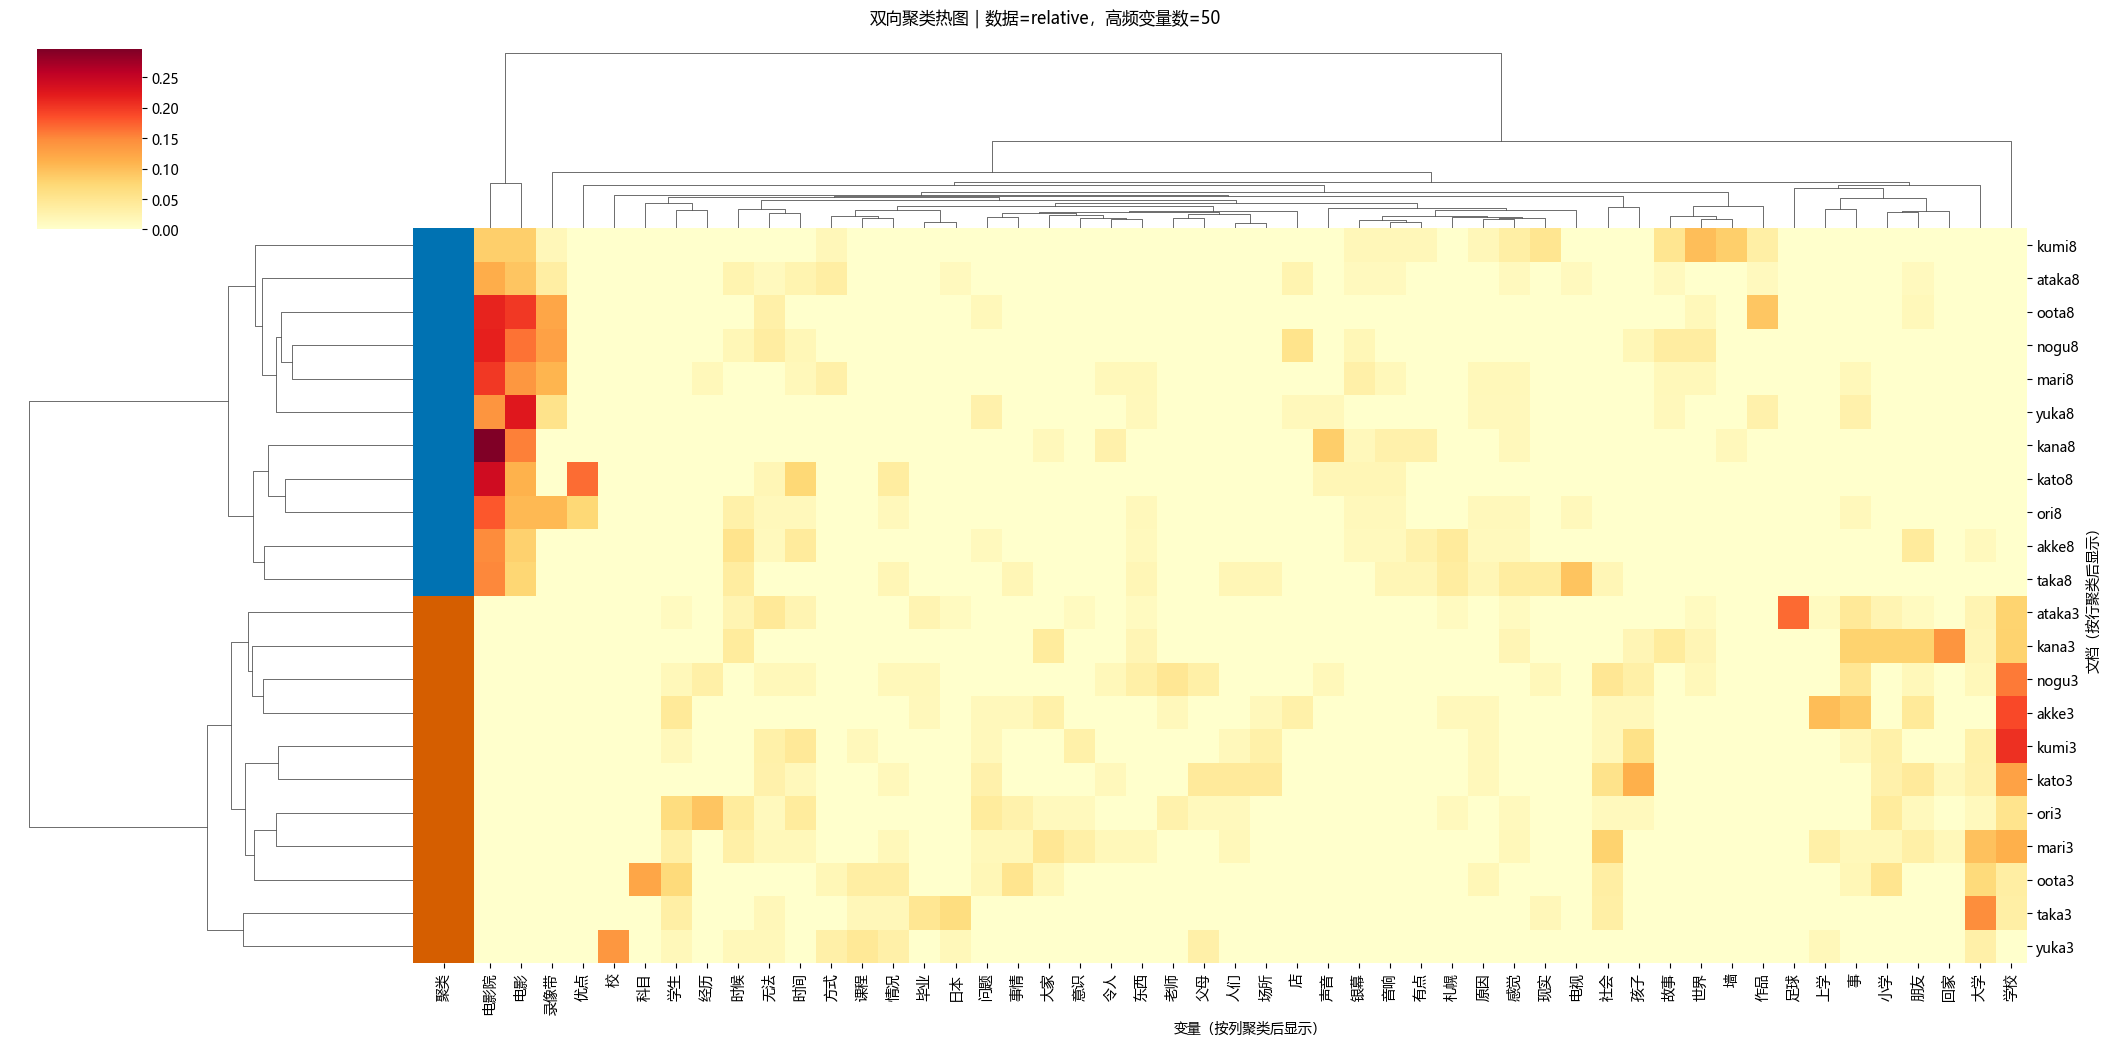

全部结果已保存至： C:\temp\hierarchical_clustering_results
 - C:\temp\hierarchical_clustering_results\dendrogram.png
 - C:\temp\hierarchical_clustering_results\bicluster_heatmap.png
 - C:\temp\hierarchical_clustering_results\bicluster_heatmap_data.csv
 - C:\temp\hierarchical_clustering_results\cluster_assignments.csv
 - C:\temp\hierarchical_clustering_results\distance_matrix.csv
 - C:\temp\hierarchical_clustering_results\matrix_count.csv
 - C:\temp\hierarchical_clustering_results\matrix_relative.csv
 - C:\temp\hierarchical_clustering_results\matrix_tfidf.csv
 - C:\temp\hierarchical_clustering_results\tokenized_documents.csv
 - C:\temp\hierarchical_clustering_results\vocabulary_statistics.csv
 - C:\temp\hierarchical_clustering_results\run_parameters.json


In [50]:
input_dir = INPUT_DIR.expanduser().resolve()
output_dir = OUTPUT_DIR.expanduser().resolve()

if not input_dir.is_dir():
    raise FileNotFoundError("找不到输入文件夹：" + str(input_dir))
output_dir.mkdir(parents=True, exist_ok=True)

paths, texts = read_documents(collect_files(input_dir))
if len(paths) < 2:
    raise ValueError("层次聚类至少需要两个文档。")

labels = make_unique_labels(paths)
tokenized, active_stopwords = tokenize_documents(texts)

(
    vocabulary, count_matrix, relative_matrix,
    tfidf_matrix, vocabulary_statistics
) = build_matrices(tokenized)

selected_matrix = select_analysis_matrix(
    CLUSTER_MATRIX_TYPE, relative_matrix, tfidf_matrix
)
if not 1 <= N_CLUSTERS <= len(paths):
    raise ValueError("N_CLUSTERS必须在1和文档数之间。")

condensed, row_tree, scipy_method = perform_clustering(
    selected_matrix, relative_matrix
)
cluster_ids = (
    cut_tree(row_tree, n_clusters=[N_CLUSTERS]).reshape(-1) + 1
)
selected_font = choose_chinese_font()

count_df = pd.DataFrame(count_matrix, index=labels, columns=vocabulary)
relative_df = pd.DataFrame(
    relative_matrix, index=labels, columns=vocabulary
)
tfidf_df = pd.DataFrame(tfidf_matrix, index=labels, columns=vocabulary)
selected_df = {
    "relative": relative_df,
    "tfidf": tfidf_df,
}[CLUSTER_MATRIX_TYPE]
distance_df = pd.DataFrame(
    squareform(condensed), index=labels, columns=labels
)

assignment_df = pd.DataFrame({
    "聚类": cluster_ids.astype(int),
    "标签": labels,
    "文件名": [path.name for path in paths],
    "相对路径": [str(path.relative_to(input_dir)) for path in paths],
    "分词数": [len(tokens) for tokens in tokenized],
}).sort_values(["聚类", "标签"]).reset_index(drop=True)

token_df = pd.DataFrame({
    "标签": labels,
    "文件名": [path.name for path in paths],
    "分词结果": [" ".join(tokens) for tokens in tokenized],
})

# 保存表格
count_df.to_csv(output_dir / "matrix_count.csv", encoding="utf-8-sig")
relative_df.to_csv(
    output_dir / "matrix_relative.csv", encoding="utf-8-sig"
)
tfidf_df.to_csv(output_dir / "matrix_tfidf.csv", encoding="utf-8-sig")
distance_df.to_csv(
    output_dir / "distance_matrix.csv", encoding="utf-8-sig"
)
assignment_df.to_csv(
    output_dir / "cluster_assignments.csv",
    encoding="utf-8-sig", index=False
)
token_df.to_csv(
    output_dir / "tokenized_documents.csv",
    encoding="utf-8-sig", index=False
)
vocabulary_statistics.to_csv(
    output_dir / "vocabulary_statistics.csv",
    encoding="utf-8-sig", index=False
)

parameters = {
    "输入文件夹": str(input_dir),
    "输出文件夹": str(output_dir),
    "文档数": len(paths),
    "筛选前N个高频变量": TOP_N_FEATURES,
    "实际变量数": len(vocabulary),
    "聚类使用的数据矩阵": CLUSTER_MATRIX_TYPE,
    "TF定义": "相对频率",
    "层次聚类方法": LINKAGE_METHOD,
    "SciPy方法": scipy_method,
    "距离": DISTANCE,
    "聚类数": N_CLUSTERS,
    "词性前缀": POS_PREFIXES,
    "停用词数": len(active_stopwords),
    "删除数字": REMOVE_DIGITS,
    "删除英文字母": REMOVE_LATIN,
    "同义词组": SYNONYM_GROUPS,
    "热图使用的数据矩阵": HEATMAP_MATRIX_TYPE,
    "热图高频变量数": HEATMAP_TOP_VARIABLES,
    "中文字体": selected_font,
}
(output_dir / "run_parameters.json").write_text(
    json.dumps(parameters, ensure_ascii=False, indent=2),
    encoding="utf-8"
)

# 显示主要结果
display(Markdown("### 运行条件"))
display(pd.DataFrame({
    "项目": [
        "文档数", "实际变量数", "聚类使用的数据矩阵",
        "层次聚类方法", "距离", "聚类数",
        "热图使用的数据矩阵", "热图变量数", "保存位置"
    ],
    "设置值": [
        len(paths), len(vocabulary), CLUSTER_MATRIX_TYPE,
        LINKAGE_METHOD, DISTANCE, N_CLUSTERS,
        HEATMAP_MATRIX_TYPE,
        min(HEATMAP_TOP_VARIABLES, len(vocabulary))
        if HEATMAP_TOP_VARIABLES > 0 else len(vocabulary),
        str(output_dir)
    ],
}))

display(Markdown("### 高频变量统计"))
display(vocabulary_statistics.head(TABLE_PREVIEW_ROWS))

display(Markdown("### 分词结果"))
display(token_df.head(TABLE_PREVIEW_ROWS))

display(Markdown(
    "### 层次聚类实际使用的数据矩阵：{}".format(
        CLUSTER_MATRIX_TYPE
    )
))
display(
    selected_df.iloc[
        :TABLE_PREVIEW_ROWS, :MATRIX_PREVIEW_SIZE
    ].round(5)
)

display(Markdown("### 各聚类的文档数"))
display(
    assignment_df.groupby("聚类").size()
    .rename("文档数").reset_index()
)

display(Markdown("### 文档聚类结果"))
display(assignment_df)

preview_size = min(MATRIX_PREVIEW_SIZE, len(labels))
display(Markdown("### 距离矩阵"))
display(
    distance_df.iloc[
        :preview_size, :preview_size
    ].round(5)
)

display(Markdown("### 层次聚类树状图"))
dendrogram_path = output_dir / "dendrogram.png"
cluster_colors = draw_dendrogram(
    row_tree, labels, cluster_ids, dendrogram_path
)

display(Markdown("### 双向聚类热图"))
heatmap_path = output_dir / "bicluster_heatmap.png"
heatmap_data = draw_bicluster_heatmap(
    relative_df, tfidf_df, vocabulary_statistics,
    row_tree, cluster_ids, cluster_colors, heatmap_path
)
heatmap_data.to_csv(
    output_dir / "bicluster_heatmap_data.csv",
    encoding="utf-8-sig"
)

print("全部结果已保存至：", output_dir)
for file_name in [
    "dendrogram.png",
    "bicluster_heatmap.png",
    "bicluster_heatmap_data.csv",
    "cluster_assignments.csv",
    "distance_matrix.csv",
    "matrix_count.csv",
    "matrix_relative.csv",
    "matrix_tfidf.csv",
    "tokenized_documents.csv",
    "vocabulary_statistics.csv",
    "run_parameters.json",
]:
    print(" -", output_dir / file_name)
